In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from myfunctions import phi, rand_TCL_ms, generate_TCL_ms

In [3]:
#punto 1
theta_a = 1
theta_b = 2
theta_c = 2
#parametri da inseire in phi (V)

V_coord = np.arange (1, 6, 1)
print  ('Valori di V:\n', V_coord) #check sui valori di V 

sigma_E = 0.5 
epsilons = generate_TCL_ms (0., sigma_E, 5) #errori gaussiani su E

E_coord = np.zeros (5)

for i in range (V_coord.size) :
    E_coord[i] = phi (i, theta_a, theta_b, theta_c) + epsilons[i]

print  ('Valori di E:\n', E_coord) #check sui valori di E


Valori di V:
 [1 2 3 4 5]
Valori di E:
 [ 2.76585037  5.17341871  9.19833191 16.79772282 26.5136791 ]


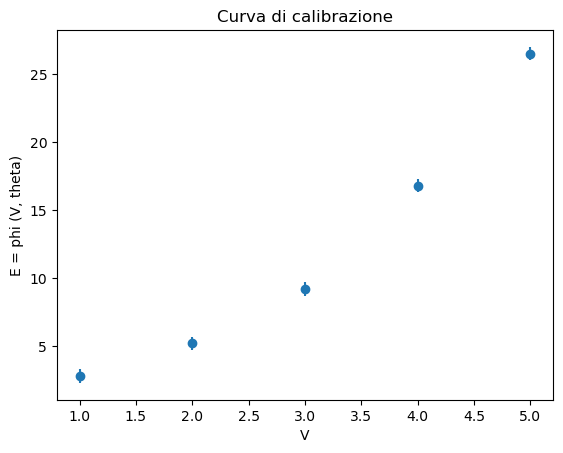

In [4]:
sigma_y = sigma_E * np.ones (5)

#plot dei punti (V, E)
fig, ax = plt.subplots()

ax.set_title ('Curva di calibrazione')
plt.xlabel ('V')
plt.ylabel ('E = phi (V, theta)')
ax.errorbar (V_coord, E_coord, xerr = 0.0, yerr = sigma_y, linestyle = 'None', marker = 'o') 
plt.show ()

In [5]:
#punto 2
from iminuit import Minuit
from iminuit.cost import LeastSquares
from myfunctions import model_para

In [6]:
a_true = 1
b_true = 2
c_true = 2

#fit con polinomio di grado 2 ovvero parabola
least_squares = LeastSquares (V_coord, E_coord, sigma_E, model_para)
my_minuit = Minuit (least_squares, a = 0., b = 0., c = 0.)
my_minuit.migrad () 
my_minuit.hesse () 

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.7661 (χ²/ndof = 0.4)     │              Nfcn = 73               │
│ EDM = 1.13e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   1.30    │   0.13    │            │            │         │         │       │
│ 1 │ b    │   -1.9    │    0.8    │            │            │         │         │       │
│ 2 │ c    │    3.4    │    1.1    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────────────────┐
│   │      a      b      c │
├───┼──────────────────────┤
│ a │ 0.0179 -0.107  0.125 │
│ b │ -0.107  0.668   -0.8 │
│ c │  0.125   -0.8   1.15 │
└───┴──────────────────────┘

In [7]:
Q_squared = my_minuit.fval
print ('Q^2 con parabola:', Q_squared)
is_valid = my_minuit.valid
print ('Successo del fit:', is_valid)
"""
#per vedere solo i paramtri stimati co relativo errore decommentare
for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') 
    
a_fit = my_minuit.values[0]
b_fit = my_minuit.values[1]
c_fit = my_minuit.values[2]
"""

Q^2 con parabola: 0.7661189509073362
Successo del fit: True


"\n#per vedere solo i paramtri stimati co relativo errore decommentare\nfor par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :\n    print(f'{par} = {val:.3f} +/- {err:.3f}') \n    \na_fit = my_minuit.values[0]\nb_fit = my_minuit.values[1]\nc_fit = my_minuit.values[2]\n"

In [8]:
"""
my_minuit.draw_mnmatrix()
#potrebbero non serivirmi questi plot
#posso stamparli per completezza
"""

'\nmy_minuit.draw_mnmatrix()\n#potrebbero non serivirmi questi plot\n#posso stamparli per completezza\n'

In [9]:
#punto 3
"""
Ho N = 5 punti, eseguire un fit con un polinomio di grado troppo superiore a N risulterebbe poco utile, 
mi limiterei quindi ai gradi N - 1 ed N 
"""
def model_fourth (x, a, b, c, d, e) :
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

In [10]:
least_squares_new = LeastSquares (V_coord, E_coord, sigma_E, model_fourth)
my_minuit_new = Minuit (least_squares_new, a = 0., b = 0., c = 0., d = 0., e = 0.)
my_minuit_new.migrad () 
my_minuit_new.hesse () 

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.5987                     │              Nfcn = 159              │
│ EDM = 0.000175 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  -0.008   │   0.006   │            │            │         │         │       │
│ 1 │ b    │   0.13    │   0.04    │            │            │         │         │       │
│ 2 │ c    │   0.62    │   0.19    │            │            │         │         │       │
│ 3 │ d    │   -0.5    │    0.6    │            │            │         │         │       │
│ 4 │ e    │    2.6    │    0.8    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────────────────────────────────────────┐
│   │        a        b        c        d        e │
├───┼──────────────────────────────────────────────┤
│ a │ 3.93e-05 -0.21e-3 -0.16e-3  1.53e-3 -0.95e-3 │
│ b │ -0.21e-3  0.00177  -0.0031  -0.0038   0.0068 │
│ c │ -0.16e-3  -0.0031   0.0344   -0.086    0.050 │
│ d │  1.53e-3  -0.0038   -0.086    0.417     -0.4 │
│ e │ -0.95e-3   0.0068    0.050     -0.4    0.656 │
└───┴──────────────────────────────────────────────┘

In [11]:
Q_squared_new = my_minuit_new.fval
print ('Q^2 con polinomio di grado 4:', Q_squared_new)
is_valid_fourth = my_minuit_new.valid
print ('Successo del fit con grado 4:', is_valid)

Q^2 con polinomio di grado 4: 0.598665799985809
Successo del fit con grado 4: True


In [12]:
#fit con polinomio di grado N
def model_fifth (x, a, b, c, d, e, f) :
    return a * x**5 + b * x**4 + c * x**3 + d * x**2 + e * x + f

In [13]:
least_squares_fifth = LeastSquares (V_coord, E_coord, sigma_E, model_fifth)
my_minuit_fifth = Minuit (least_squares_fifth, a = 0., b = 0., c = 0., d = 0., e = 0., f = 0.)
my_minuit_fifth.migrad () 
my_minuit_fifth.hesse () 

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.9e-06                    │              Nfcn = 256              │
│ EDM = 4.35e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  -0.0175  │  0.0013   │            │            │         │         │       │
│ 1 │ b    │   0.120   │   0.008   │            │            │         │         │       │
│ 2 │ c    │   0.26    │   0.04    │            │            │         │         │       │
│ 3 │ d    │   -2.19   │   0.17    │            │            │         │         │       │
│ 4 │ e    │    5.9    │    0.6    │            │            │         │         │       │
│ 5 │ f    │   -1.3    │    0.8    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────────────────────────────────────┐
│   │         a         b         c         d         e         f │
├───┼─────────────────────────────────────────────────────────────┤
│ a │  1.78e-06   -7.8e-6  -15.3e-6   17.3e-6  220.8e-6 -216.4e-6 │
│ b │   -7.8e-6  6.79e-05  -0.11e-3  -0.23e-3   0.28e-3   0.27e-3 │
│ c │  -15.3e-6  -0.11e-3   0.00162   -0.0027   -0.0053    0.0077 │
│ d │   17.3e-6  -0.23e-3   -0.0027    0.0293    -0.070     0.038 │
│ e │  220.8e-6   0.28e-3   -0.0053    -0.070     0.387      -0.4 │
│ f │ -216.4e-6   0.27e-3    0.0077     0.038      -0.4     0.633 │
└───┴─────────────────────────────────────────────────────────────┘

In [14]:
Q_squared_fifth = my_minuit_fifth.fval
print ('Q^2 con polinomio di grado 5:', Q_squared_fifth)
is_valid_fifth = my_minuit_fifth.valid
print ('Successo del fit con grado 5:', is_valid_fifth)

Q^2 con polinomio di grado 5: 4.900116456732015e-06
Successo del fit con grado 5: True


In [15]:
#punto 4
from scipy.stats import f
from stats import stats
from myfunctions import sturges, phi_hat

In [16]:
#definisco una serie di parametri che poi usero nella distribuzione di Fisher - Snedecor
p1 = 2
p2 = 3
n_data = 5 
df1 = p2 - p1
df2 = n_data - p2

def model_cube (x, a, b, c, d) :
    return a * x**3 + b * x**2 + c * x + d

In [17]:
N_toy = 1000

a_true = 1
b_true = 2
c_true = 2

Q_squares_para = []
Q_squares_cube = []

V_coord_toy = np.arange (1, 6, 1)
E_coord_toy = np.zeros (n_data)

for i_toy in range (N_toy) :
    epsilons_toy = generate_TCL_ms (0., sigma_E, n_data)
    for i in range (V_coord_toy.size) :
        E_coord_toy[i] = phi (V_coord_toy[i], theta_a = 1, theta_b = 2, theta_c = 2) + epsilons_toy[i]
        
    least_squares_para = LeastSquares (V_coord_toy, E_coord_toy, sigma_y, model_para)
    least_squares_cube = LeastSquares (V_coord_toy, E_coord_toy, sigma_y, model_cube)
    my_minuit_toy_para = Minuit (least_squares_para, a = 0, b = 0, c = 0)  
    my_minuit_toy_cube = Minuit (least_squares_cube, a = 0, b = 0, c = 0, d = 0) 
    my_minuit_toy_para.migrad ()  
    my_minuit_toy_para.hesse ()   
    my_minuit_toy_cube.migrad () 
    my_minuit_toy_cube.hesse ()
    if my_minuit_toy_para.valid : 
        Q_squares_para.append (my_minuit_toy_para.fval)
    if my_minuit_toy_cube.valid : 
        Q_squares_cube.append (my_minuit_toy_cube.fval)

    
    phi_hat_values = []    
    for (Qs_1, Qs_2) in zip (Q_squares_para, Q_squares_cube) :
        phi_hat_values.append (phi_hat (Qs_1, Qs_2, p1, p2))


In [18]:
print (len (phi_hat_values))

1000


In [19]:
#print (phi_hat_values) 
#non è obblighatorio eseguire questa cella

In [20]:

N_bins = int (np.sqrt (len (phi_hat_values)))
print ('Numero di bin:', N_bins)

phi_min, phi_max = np.min(phi_hat_values), np.max (phi_hat_values)
diff = phi_max - phi_min 
#print (diff)
bin_edges = np.linspace (phi_min - 0.01 * diff, phi_max + 0.01 * diff, N_bins)


Numero di bin: 31


In [21]:
print ('Minimo del sample phi_hat', phi_min)
print ('Massimo del sample phi_hat',  phi_max)

Minimo del sample phi_hat 5.196950974013908e-06
Massimo del sample phi_hat 3831843.7735342854


In [22]:
g = lambda x : f.pdf(x, dfn = df1, dfd = df2, loc = 0, scale = 1) 
#distribuzione di Fisher - Snedecor per i valori specifici del nostro caso

x_coord = np.linspace (0, 1000000, 1000000) 
y_coord = g (x_coord)

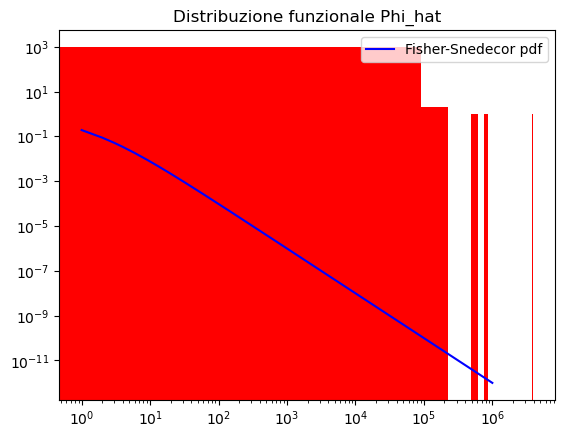

In [23]:
fig, ax = plt.subplots ()
ax.set_title ('Distribuzione funzionale Phi_hat')
ax.set_xscale ('log')
ax.set_yscale ('log')
plt.plot (x_coord, y_coord, label = 'Fisher-Snedecor pdf', color = 'b')
ax.hist (phi_hat_values, bins = bin_edges, color = 'r',)
plt.legend()
plt.show ()
